In [4]:
from geomloss.kernel_samples import gaussian_kernel

Using device: cuda

--- Testing with Kernel Blur = 0.10 ---
  Very Clustered: Energy = 0.291144
  Spread Out (Uniform): Energy = 0.024399
  Two Distinct Clusters: Energy = 0.180855

--- Testing with Kernel Blur = 0.50 ---
  Very Clustered: Energy = 0.911756
  Spread Out (Uniform): Energy = 0.145469
  Two Distinct Clusters: Energy = 0.463992

--- Testing with Kernel Blur = 1.00 ---
  Very Clustered: Energy = 0.976480
  Spread Out (Uniform): Energy = 0.399399
  Two Distinct Clusters: Energy = 0.565856

Plot saved to custom_kernel_energy_diversity_example.png


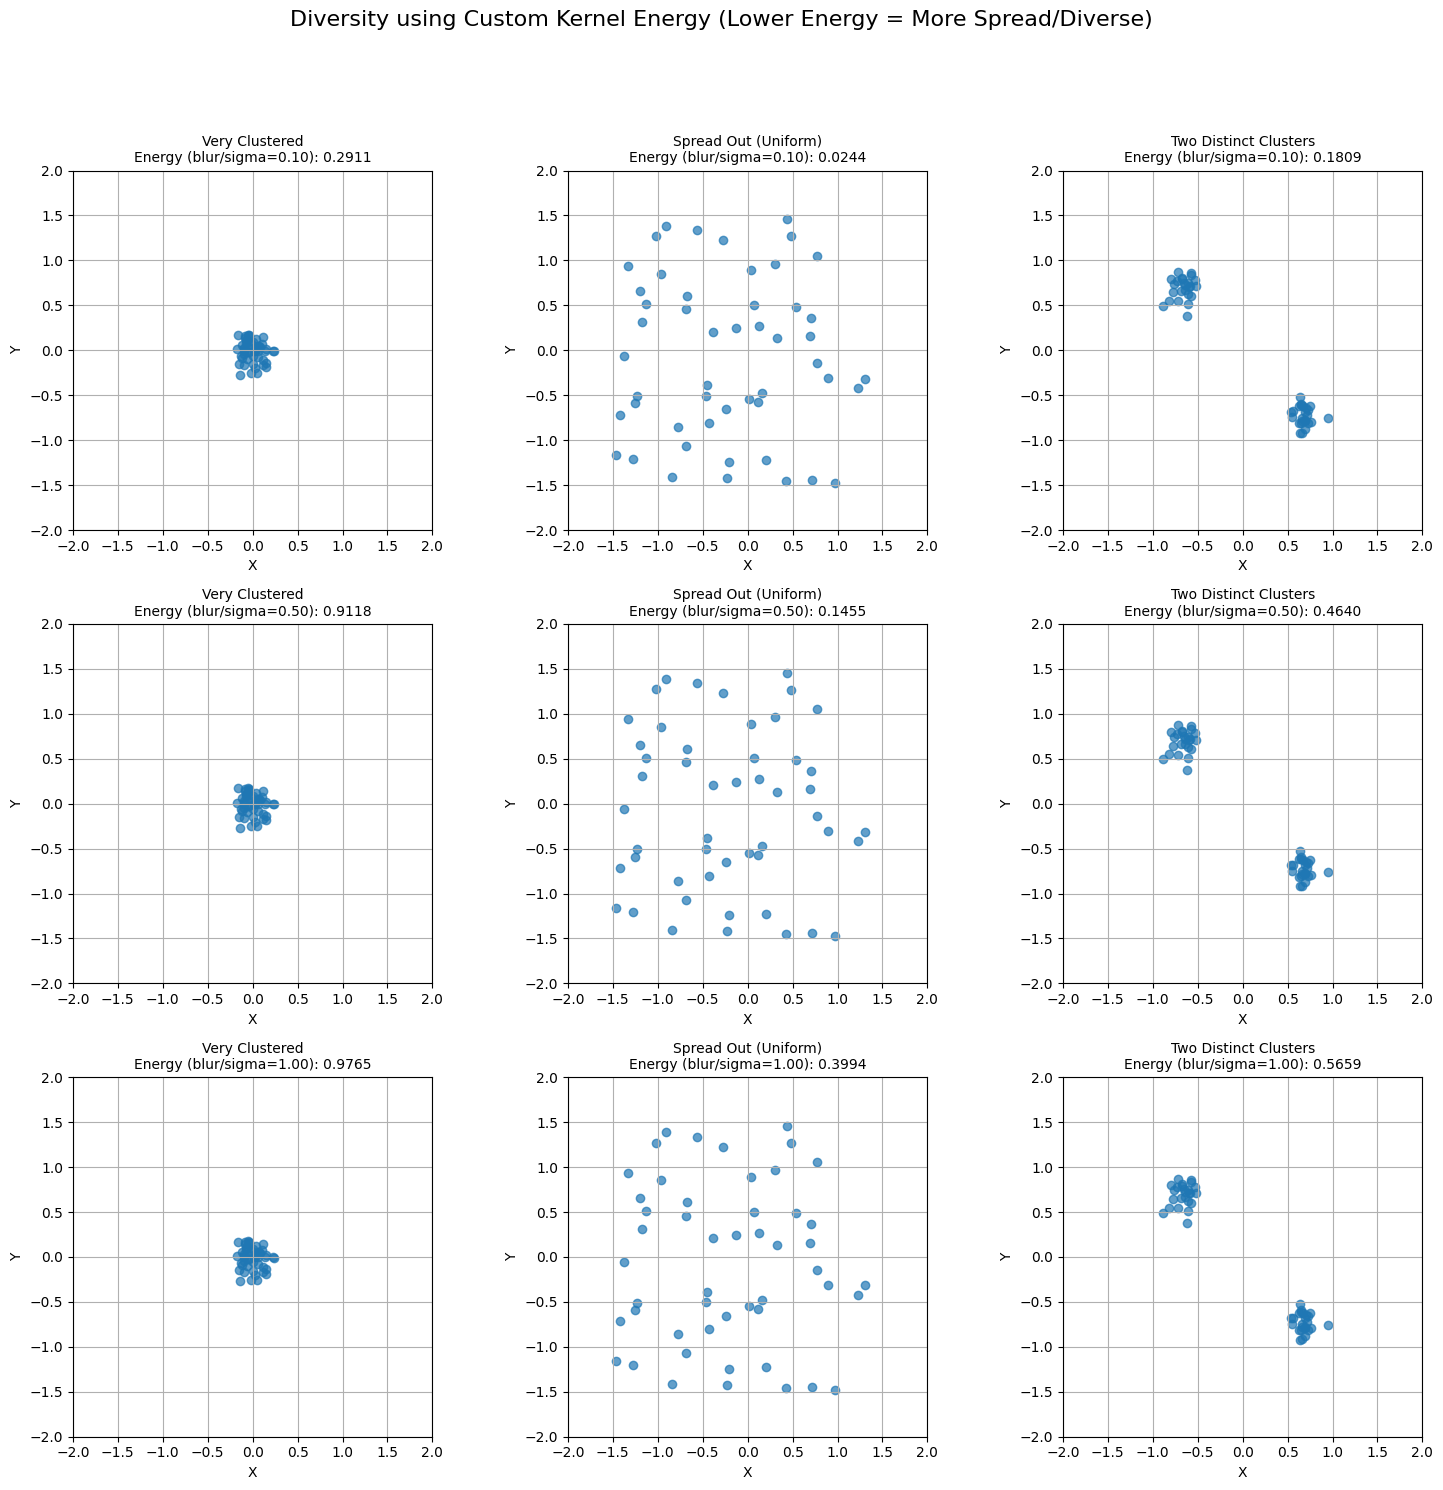

In [5]:
import torch
# from geomloss import SamplesLoss # Not strictly needed if we compute energy directly with custom kernel
# from geomloss.kernels import GaussianKernel # Replaced by custom kernel
import matplotlib.pyplot as plt
import numpy as np

def plot_points_and_energy(points, energy_value, title, ax, sigma):
    """Helper function to plot points and display their energy."""
    points_np = points.cpu().numpy()
    ax.scatter(points_np[:, 0], points_np[:, 1], alpha=0.7)
    ax.set_title(f"{title}\nEnergy (blur/sigma={sigma:.2f}): {energy_value:.4f}", fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    # Set fixed limits for better comparison
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)


# --- Configuration ---
num_points = 50
feature_dim = 2 # 2D points
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Create Point Sets ---
points_clustered = torch.randn(num_points, feature_dim, device=device) * 0.1 
points_clustered += torch.tensor([0.0, 0.0], device=device) 

points_spread = torch.rand(num_points, feature_dim, device=device) * 3.0 - 1.5 

points_two_clusters1 = torch.randn(num_points // 2, feature_dim, device=device) * 0.1 + torch.tensor([-0.7, 0.7], device=device)
points_two_clusters2 = torch.randn(num_points // 2, feature_dim, device=device) * 0.1 + torch.tensor([0.7, -0.7], device=device)
points_two_clusters = torch.cat([points_two_clusters1, points_two_clusters2], dim=0)

point_sets = [
    {"name": "Very Clustered", "points": points_clustered},
    {"name": "Spread Out (Uniform)", "points": points_spread},
    {"name": "Two Distinct Clusters", "points": points_two_clusters},
]

# --- Kernel and Loss Configuration ---
# 'blur' in your custom kernel acts as 'sigma'
kernel_blurs_to_test = [0.1, 0.5, 1.0] 

fig, axes = plt.subplots(len(kernel_blurs_to_test), len(point_sets), 
                         figsize=(5 * len(point_sets), 5 * len(kernel_blurs_to_test)))
fig.suptitle("Diversity using Custom Kernel Energy (Lower Energy = More Spread/Diverse)", fontsize=16, y=1.02)


for i, blur_val in enumerate(kernel_blurs_to_test):
    print(f"\n--- Testing with Kernel Blur = {blur_val:.2f} ---")
    
    for j, point_set_data in enumerate(point_sets):
        points = point_set_data["points"] # Shape (N, D)
        name = point_set_data["name"]

        current_num_points = points.shape[0]
        if current_num_points == 0:
            print(f"  {name}: Energy = N/A (0 points)")
            ax_current = axes[i, j] if len(kernel_blurs_to_test) > 1 else (axes[j] if len(point_sets) > 1 else axes)
            ax_current.set_title(f"{name}\nEnergy (blur={blur_val:.2f}): N/A", fontsize=10)
            ax_current.set_xlim(-2,2); ax_current.set_ylim(-2,2); ax_current.grid(True)
            continue

        # Uniform weights for the points
        weights = torch.ones(current_num_points, device=device) / current_num_points # (N,)
        
        # Calculate Gram matrix K_xx where K_xx[i,j] = Kernel(x_i, x_j)
        # custom_gaussian_kernel expects (N,D), (M,D) and returns (N,M)
        # For K_xx, x and y are the same.
        K_xx = gaussian_kernel(points, points, blur=blur_val) # Shape (N, N)

        # Calculate energy: Sum_ij w_i * w_j * K(x_i, x_j)
        # This is w^T @ K_xx @ w 
        # weights is (N,), K_xx is (N,N)
        # energy_value = weights @ K_xx @ weights 
        # More explicitly for clarity:
        term1 = torch.mv(K_xx, weights) # K_xx @ w -> (N,)
        energy_value = torch.dot(weights, term1) # w^T @ (K_xx @ w) -> scalar
        
        print(f"  {name}: Energy = {energy_value.item():.6f}")

        # Plotting
        ax_current = axes[i, j] if len(kernel_blurs_to_test) > 1 else (axes[j] if len(point_sets) > 1 else axes)
        plot_points_and_energy(points, energy_value.item(), name, ax_current, blur_val)

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.savefig("custom_kernel_energy_diversity_example.png")
print("\nPlot saved to custom_kernel_energy_diversity_example.png")
plt.show()

Using device: cuda

--- Running Test Case: Equal Size, Separated ---
  Hungarian Distance (sum of L1 costs for matched pairs): 39.1621
  Sinkhorn Distance (Manual Log-Domain, blur=0.05, cost=L1): 3.9162

--- Running Test Case: Equal Size, Overlapping ---
  Hungarian Distance (sum of L1 costs for matched pairs): 15.9418
  Sinkhorn Distance (Manual Log-Domain, blur=0.05, cost=L1): 1.0665

--- Running Test Case: Unequal Size, Separated ---
  Hungarian Distance (sum of L1 costs for matched pairs): 22.7776
  Sinkhorn Distance (Manual Log-Domain, blur=0.05, cost=L1): 3.0822

--- Running Test Case: Unequal Size, Alpha surrounds Beta ---
  Hungarian Distance (sum of L1 costs for matched pairs): 2.0086
  Sinkhorn Distance (Manual Log-Domain, blur=0.05, cost=L1): 1.6781

Plot saved to hungarian_vs_sinkhorn_logdomain_comparison.png


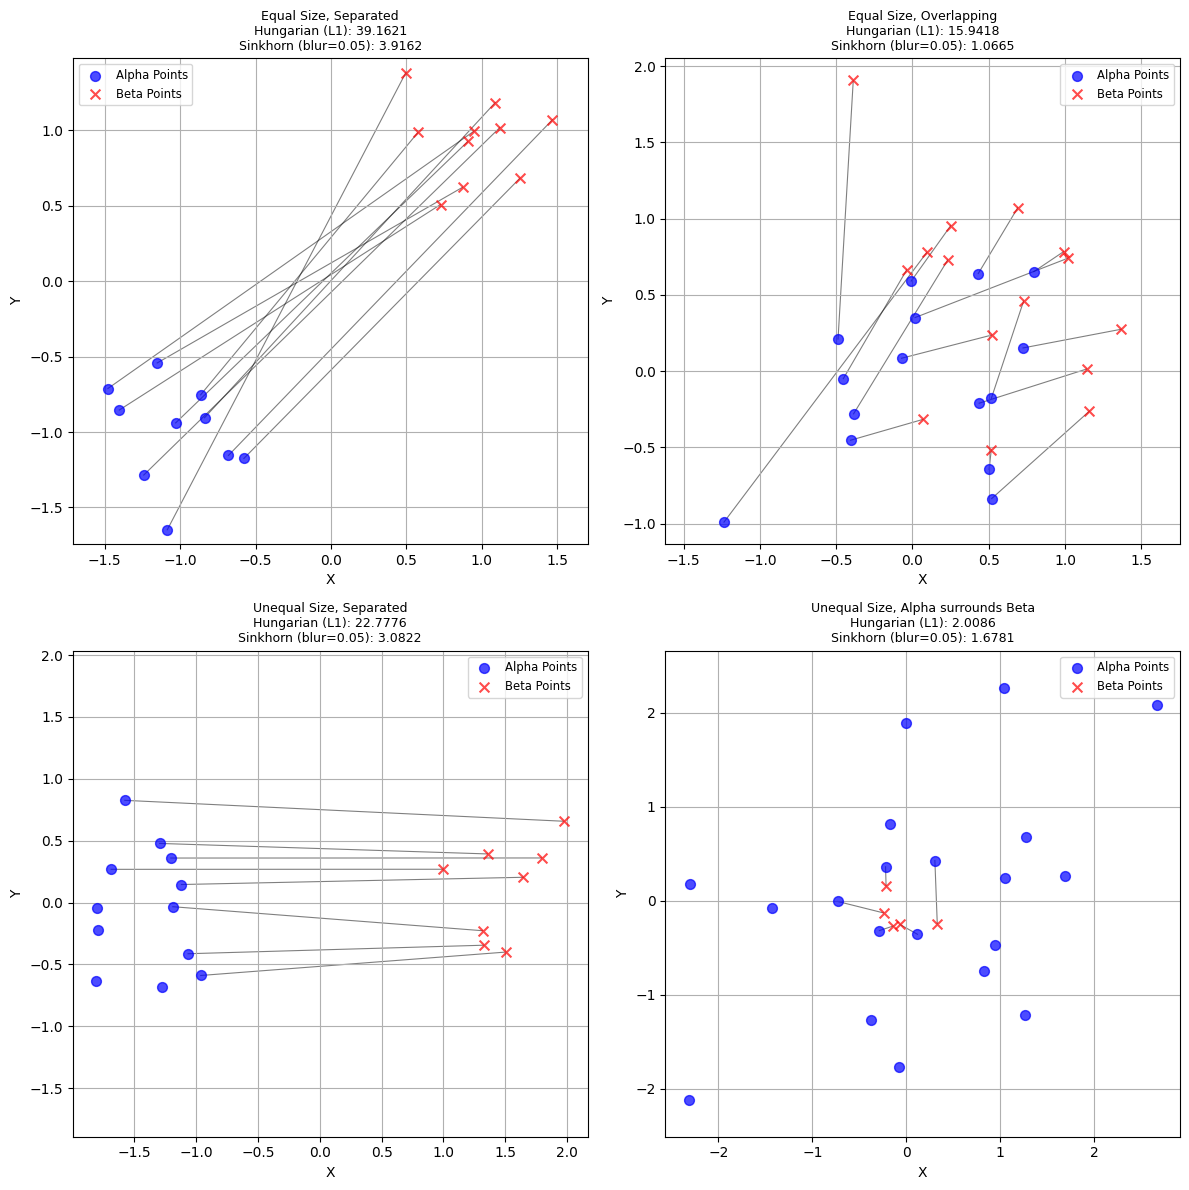

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
# from geomloss import SamplesLoss # Not used for manual Sinkhorn distance calculation in this version

def generate_points(num_points, dim=2, center=[0,0], spread=1.0, device='cpu'):
    """Generates a set of random points."""
    points = torch.randn(num_points, dim, device=device) * spread + torch.tensor(center, device=device, dtype=torch.float32)
    return points

def sinkhorn_log_domain_standalone(log_K_geom_nm, marg_n, marg_m, nits=20, log_clamp_val=1e-30, debug_ot=False):
    """
    Log-domain Sinkhorn iterations for numerical stability (standalone version for non-batched inputs).
    Args:
        log_K_geom_nm (torch.Tensor): Log of the kernel matrix (N, M). log_K_geom_nm = -C_nm / blur.
        marg_n (torch.Tensor): Marginals for the first set of points (N,). Should sum to 1.
        marg_m (torch.Tensor): Marginals for the second set of points (M,). Should sum to 1.
        nits (int): Number of Sinkhorn iterations.
        log_clamp_val (float): Smallest value for clamping marginals before log.
        debug_ot (bool): Enable debug prints.
    Returns:
        log_u (torch.Tensor): Log of dual potentials for the first set (N,).
        log_v (torch.Tensor): Log of dual potentials for the second set (M,).
    """
    if debug_ot:
        print(f"--- sinkhorn_log_domain_standalone (Start) ---")
        print(f"  log_K_geom_nm shape: {log_K_geom_nm.shape}, min: {log_K_geom_nm.min():.3e}, max: {log_K_geom_nm.max():.3e}")
        print(f"  marg_n shape: {marg_n.shape}, sum: {marg_n.sum():.3e}")
        print(f"  marg_m shape: {marg_m.shape}, sum: {marg_m.sum():.3e}")

    log_u = torch.zeros_like(marg_n)  # (N,)
    log_v = torch.zeros_like(marg_m)    # (M,)

    for i in range(nits):
        # Update log_v (corresponds to beta in previous notation, or g in geomloss)
        log_marg_m_clamped = torch.log(marg_m.clamp(min=log_clamp_val))
        # log_K_geom_nm.transpose(-1, -2) is (M, N)
        # log_u.unsqueeze(0) is (1, N)
        # The sum is over N (dim=1 of the (M,N) result of addition)
        log_sum_exp_val_v = torch.logsumexp(log_K_geom_nm.transpose(-1, -2) + log_u.unsqueeze(0), dim=1) 
        log_v_new = -log_sum_exp_val_v + log_marg_m_clamped
        log_v = torch.nan_to_num(log_v_new, nan=0.0, posinf=0.0, neginf=-1e6)

        # Update log_u (corresponds to alpha in previous notation, or f in geomloss)
        log_marg_n_clamped = torch.log(marg_n.clamp(min=log_clamp_val))
        # log_K_geom_nm is (N, M)
        # log_v.unsqueeze(0) is (1, M)
        # The sum is over M (dim=1 of the (N,M) result of addition)
        log_sum_exp_val_u = torch.logsumexp(log_K_geom_nm + log_v.unsqueeze(0), dim=1) 
        log_u_new = -log_sum_exp_val_u + log_marg_n_clamped
        log_u = torch.nan_to_num(log_u_new, nan=0.0, posinf=0.0, neginf=-1e6)
        
        if debug_ot and i % (nits // 5 if nits >=5 else 1) == 0 : 
            print(f"    Iter {i} log_v: min: {log_v.min():.3e}, max: {log_v.max():.3e}")
            print(f"    Iter {i} log_u: min: {log_u.min():.3e}, max: {log_u.max():.3e}")
            
    if debug_ot: print(f"--- sinkhorn_log_domain_standalone (End) ---")
    return log_u, log_v


def plot_matching_and_distances(ax, alpha_points_np, beta_points_np, 
                                row_ind, col_ind, 
                                hungarian_dist, sinkhorn_dist, 
                                title=""):
    """Plots the points, the Hungarian matching, and displays distances."""
    ax.scatter(alpha_points_np[:, 0], alpha_points_np[:, 1], c='blue', marker='o', label='Alpha Points', s=50, alpha=0.7, zorder=2)
    ax.scatter(beta_points_np[:, 0], beta_points_np[:, 1], c='red', marker='x', label='Beta Points', s=50, alpha=0.7, zorder=2)

    if row_ind is not None and col_ind is not None:
        for i in range(len(row_ind)):
            ax.plot([alpha_points_np[row_ind[i], 0], beta_points_np[col_ind[i], 0]],
                    [alpha_points_np[row_ind[i], 1], beta_points_np[col_ind[i], 1]],
                    'k-', alpha=0.5, linewidth=0.8, zorder=1)
    
    ax.set_title(f"{title}\nHungarian (L{cost_p_norm}): {hungarian_dist:.4f}\nSinkhorn (blur={sinkhorn_blur:.2f}): {sinkhorn_dist:.4f}", fontsize=9)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(fontsize='small')
    ax.grid(True)
    ax.axis('equal')


if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Configuration for Distances ---
    cost_p_norm = 1  # p-norm for cost matrix for Hungarian (1 for L1, 2 for L2)
    
    # Sinkhorn parameters for manual implementation
    sinkhorn_blur = 0.05  # Epsilon, regularization strength.
    sinkhorn_nits = 50    # Number of Sinkhorn iterations
    cost_type_ot = 'L1'   # 'L1' or 'L2_sq' for the cost matrix C fed into Sinkhorn
    debug_ot_standalone = False # Enable for detailed Sinkhorn prints

    # --- Test Cases ---
    test_cases = [
        {"name": "Equal Size, Separated", 
         "n_alpha": 10, "n_beta": 10, 
         "center_alpha": [-1, -1], "center_beta": [1, 1], 
         "spread_alpha": 0.3, "spread_beta": 0.3},
        {"name": "Equal Size, Overlapping", 
         "n_alpha": 15, "n_beta": 15, 
         "center_alpha": [0, 0], "center_beta": [0.5, 0.5], 
         "spread_alpha": 0.5, "spread_beta": 0.5},
        {"name": "Unequal Size, Separated", 
         "n_alpha": 12, "n_beta": 8, 
         "center_alpha": [-1.5, 0], "center_beta": [1.5, 0], 
         "spread_alpha": 0.4, "spread_beta": 0.4},
        {"name": "Unequal Size, Alpha surrounds Beta", 
         "n_alpha": 20, "n_beta": 5, 
         "center_alpha": [0, 0], "center_beta": [0, 0], 
         "spread_alpha": 1.0, "spread_beta": 0.2},
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, params in enumerate(test_cases):
        print(f"\n--- Running Test Case: {params['name']} ---")
        ax = axes[i]

        alpha_points = generate_points(params["n_alpha"], center=params["center_alpha"], spread=params["spread_alpha"], device=device)
        beta_points = generate_points(params["n_beta"], center=params["center_beta"], spread=params["spread_beta"], device=device)

        # 1. Hungarian Distance
        cost_matrix_hungarian_torch = torch.cdist(alpha_points, beta_points, p=cost_p_norm)
        cost_matrix_hungarian_np = cost_matrix_hungarian_torch.cpu().numpy()
        row_ind, col_ind = linear_sum_assignment(cost_matrix_hungarian_np)
        hungarian_distance = cost_matrix_hungarian_np[row_ind, col_ind].sum()
        print(f"  Hungarian Distance (sum of L{cost_p_norm} costs for matched pairs): {hungarian_distance:.4f}")

        # 2. Sinkhorn Distance (Optimal Transport Cost) - Manual Log-Domain Implementation
        # Cost matrix C for OT
        if cost_type_ot == 'L1':
            C_ot = torch.cdist(alpha_points, beta_points, p=1)
        elif cost_type_ot == 'L2_sq':
            C_ot = torch.cdist(alpha_points, beta_points, p=2).pow(2)
        else: # Default L2_sq
            C_ot = torch.cdist(alpha_points, beta_points, p=2).pow(2)

        log_K_geom_ot = -C_ot / sinkhorn_blur

        # Uniform marginals
        marg_alpha = torch.full((params["n_alpha"],), 1.0 / params["n_alpha"] if params["n_alpha"] > 0 else 1.0, device=device)
        marg_beta = torch.full((params["n_beta"],), 1.0 / params["n_beta"] if params["n_beta"] > 0 else 1.0, device=device)
        
        if params["n_alpha"] == 0 or params["n_beta"] == 0:
            sinkhorn_distance_val = float('nan') # Cannot compute if one set is empty
            print(f"  Sinkhorn Distance (Manual Log-Domain): NaN (empty point set)")
        else:
            log_u, log_v = sinkhorn_log_domain_standalone(log_K_geom_ot, marg_alpha, marg_beta, 
                                                          nits=sinkhorn_nits, debug_ot=debug_ot_standalone)
            
            # Reconstruct transport plan P_ij = u_i * K_ij * v_j = exp(log_u_i + log_v_j + log_K_ij)
            P_transport_plan = torch.exp(log_u.unsqueeze(-1) + log_v.unsqueeze(0) + log_K_geom_ot)
            
            # Sinkhorn distance (OT cost) = sum_{i,j} P_ij * C_ij
            sinkhorn_distance_val = (P_transport_plan * C_ot).sum().item()
            print(f"  Sinkhorn Distance (Manual Log-Domain, blur={sinkhorn_blur:.2f}, cost={cost_type_ot}): {sinkhorn_distance_val:.4f}")
            if debug_ot_standalone:
                print(f"    P_transport_plan sum: {P_transport_plan.sum():.4f}") # Should be close to 1
                print(f"    P_transport_plan row sums (approx marg_alpha): {P_transport_plan.sum(dim=1)}")
                print(f"    P_transport_plan col sums (approx marg_beta): {P_transport_plan.sum(dim=0)}")


        # Plotting
        plot_matching_and_distances(ax, 
                                    alpha_points.cpu().numpy(), 
                                    beta_points.cpu().numpy(),
                                    row_ind, col_ind,
                                    hungarian_distance,
                                    sinkhorn_distance_val,
                                    title=params["name"])
    
    plt.tight_layout()
    plt.savefig("hungarian_vs_sinkhorn_logdomain_comparison.png")
    print("\nPlot saved to hungarian_vs_sinkhorn_logdomain_comparison.png")
    plt.show()
